In [1]:
library(readODS)
library(ggplot2)

In [2]:
options(repr.plot.width = 24, repr.plot.height = 17, repr.plot.pointsize = 24)

In [3]:
data <- read_ods("/home/adufour/work/table/epilepsie/additional_file5.ods")

In [4]:
data <- data[data$p_val_adj < 0.05,]

In [5]:
data_neg <- data[data$avg_log2FC < 0,]
data_pos <- data[data$avg_log2FC > 0,]

In [6]:
data_table_neg <- as.data.frame(table(data_neg$time, data_neg$cluster))
data_table_neg$Freq <- data_table_neg$Freq*(-1)

In [7]:
data_table_pos <- as.data.frame(table(data_pos$time, data_pos$cluster))

In [8]:
data_table_merged <- rbind(data_table_pos, data_table_neg)

In [9]:
data_table_merged$Cluster <- as.factor(gsub("_", ".", data_table_merged$Var2))

In [10]:
cluster_color <- c("0.0" = "#238b45", "1" = "#cccccc", "2" = "#f768a1", "4" = "#bae1ff", "0.2" = "#bae4b3", "0.3" = "#edf8e9", "0.1" = "#74c476", "3.0" = "#fdf498", "3.1" = "#807dba", "3.2" = "#4a1486", "3.3" = "#ac8fff")

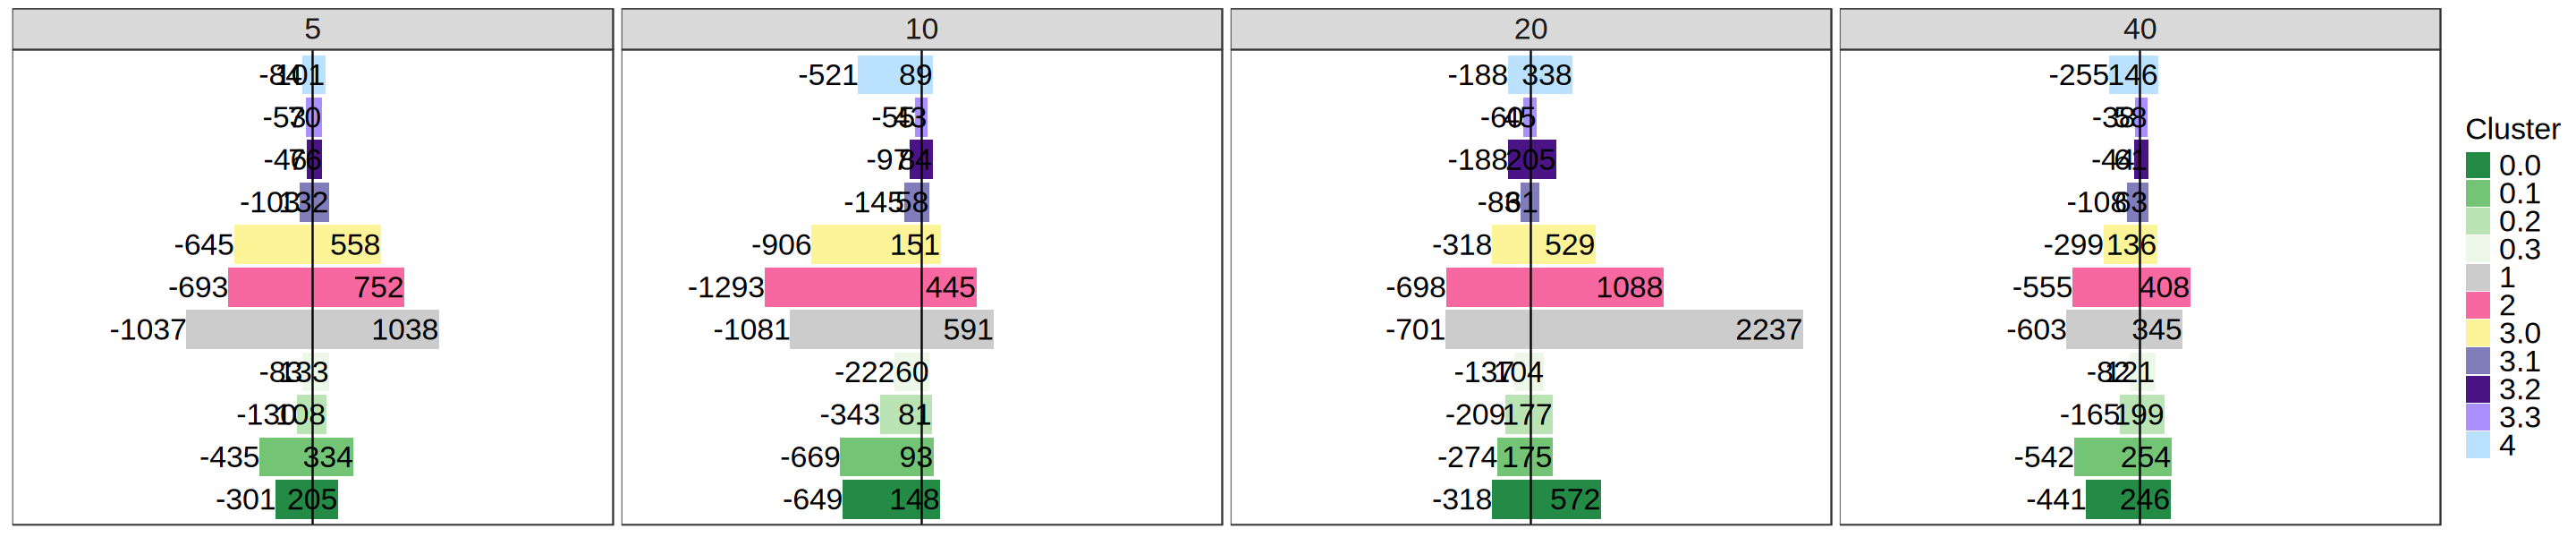

In [ ]:
p <- ggplot(data = data_table_merged, aes(x = Cluster, y = Freq, fill = Cluster)) +
  geom_col() +
  geom_hline(yintercept = 0, colour="black") +
  scale_fill_manual(values = cluster_color) +
  geom_text(aes(label = Freq), 
    hjust = 1,
    size = 7) +
  coord_flip() +
  theme_bw() +
  ylim(-2250, 2250) +
  theme(
    panel.grid = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.x = element_blank(),
    legend.title = element_text(size = 20),
    axis.text.y = element_blank(),
    legend.text = element_text(size = 20),
    text = element_text(size = 25),
  ) +
  facet_grid(. ~ Var1)
p

In [28]:
ggsave("/home/adufour/work/plots/epilepsie/barplot_differentiel.svg", p, height = 5, width = 48)